# DATA CLEANING & PREPROCESSING

In [59]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

### Configurations

In [60]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 30 # 50

### Data fetching
- Only give tha parent folder name ( Eg : data folde has 3 folders class_1, class_2, class_3 each class folder has own images)
- Auto set the label as the folder name of that particular image in

In [61]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    shuffle=True,
    image_size = IMAGE_SIZE,
    batch_size= BATCH_SIZE,
)

Found 2152 files belonging to 3 classes.


In [62]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [63]:
len(dataset) # Why 68 - It is due to batch size 32, dataset contain  68, 32 size batches but last batch doesn not have 32

68

### Showing one image

In [64]:
type(dataset)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [65]:
for i in dataset.take(1):
    # print (i[0][0]) # First image
    print (i[1][0]) # First label
    print(len(i))
    print(len(i[0]))
    print(len(i[1]))

tf.Tensor(0, shape=(), dtype=int32)
2
32
32


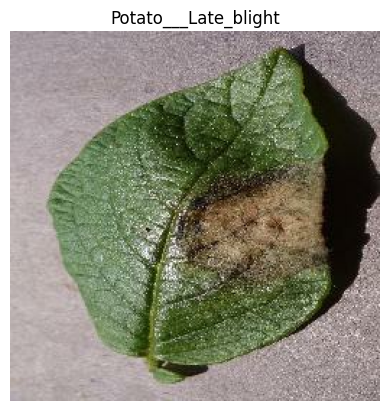

In [66]:
# dataset is collection of 68 batches each batch contain of 32 images + 32 label as seperate two lists

for img_batch, label_batch in dataset.take(1):
    # print (i[0][0]) # First image
    plt.imshow(img_batch[0].numpy().astype('uint8')) # First batch first image show
    plt.title(class_names[label_batch[0]])
    plt.axis('off')

### Showing multiple images

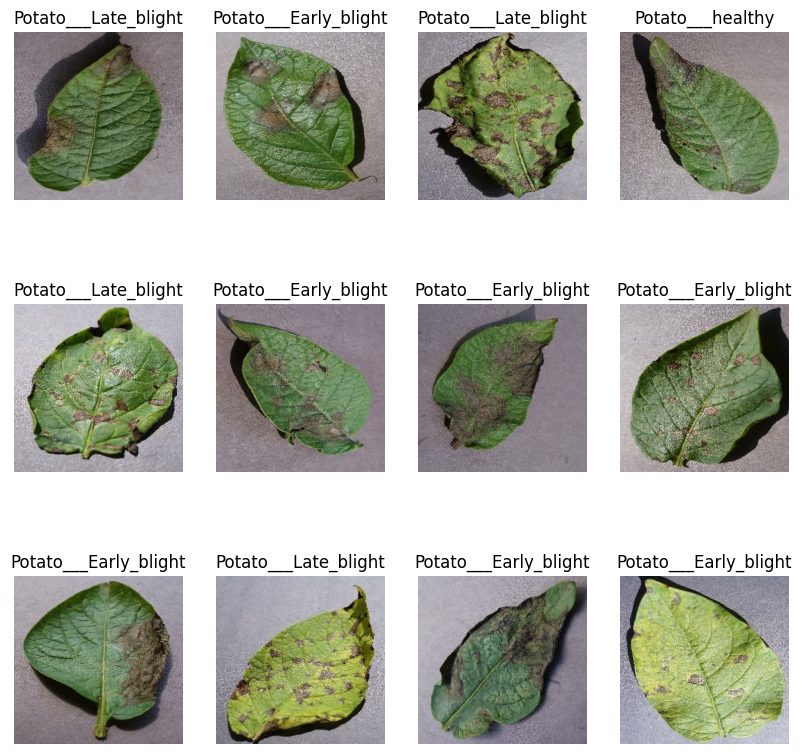

In [67]:
plt.figure(figsize=(10, 10))

for img_batch, lable_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(img_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

### Train test splitting

80% ==> training<br>
20% ==> 10% validation 10% testing

In [10]:
train_size = int(len(dataset)*0.8)
train_size

54

In [11]:
train_ds = dataset.take(train_size)
print(len(train_ds))
      
test_val_ds = dataset.skip(train_size)
print(len(test_val_ds))

54
14


In [12]:
val_size =int(len(dataset)* 0.1)
val_size

6

In [13]:
val_ds = test_val_ds.take(val_size)
len(val_ds)

6

In [14]:
test_ds = test_val_ds.skip(val_size)
len(test_ds)

8

In [68]:
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1500):

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=123)
        
    ds_size = int(len(ds))
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)
    # rest of part for test
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [69]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


In [70]:
'''
*** cache() : Stores the dataset in memory after loading it once.
    - First epoch -> loads from disk
    - Next epochs -> uses memory (faster)

*** What is buffer size? While the model is training on Batch 1 : 
    - GPU training on Batch 1
    - CPU preparing Batch 2
    The prepared batches are stored in a temporary area called a buffer, Example: prefetch(2) > Keep 2 batches ready in advance

*** AUTOTUNE lets TensorFlow automatically choose the best buffer size
'''

'\n*** cache() : Stores the dataset in memory after loading it once.\n    - First epoch -> loads from disk\n    - Next epochs -> uses memory (faster)\n\n*** What is buffer size? While the model is training on Batch 1 : \n    - GPU training on Batch 1\n    - CPU preparing Batch 2\n    The prepared batches are stored in a temporary area called a buffer, Example: prefetch(2) > Keep 2 batches ready in advance\n\n*** AUTOTUNE lets TensorFlow automatically choose the best buffer size\n'

In [71]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

### Scaling, we will supply this layer when building the model

In [72]:
resize_rescale_layer = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE), # ensure 256 x 256
    layers.Rescaling(1.0/255) # 0 - 1
])

### Data Augmentation
- Data augmentation is a technique used to increase the diversity of training data by applying random transformations to images
- Instead of collecting new images, we create modified versions of existing images

In [73]:
data_augmentation_layer = tf.keras.Sequential([
    # Randomly flips images : left <-> right (horizontal) & up <-> down (vertical), Ex : Cat facing left -> flipped cat facing right
    layers.RandomFlip('horizontal_and_vertical'),

    # Randomly rotates the image -> 0.2 means up to 20% of 360 -> nearly ±72 degrees
    layers.RandomRotation(0.2)
])

## CNN Model
- **input shape** of the image must be defined in the first Conv layer only
- Other Conv layers we no need to define **input shape***
- all Conv layers must define the **activation fucntion** , **kernel size** & **output cahnnels**

In [74]:
# OLD BROKEN MODEL STILL IN MEMORY (MOST COMMON) TensorFlow keeps graph state
tf.keras.backend.clear_session()

In [75]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = int(len(class_names))

model = models.Sequential([
    layers.Input(shape=input_shape),
    resize_rescale_layer,
    data_augmentation_layer,
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    layers.Flatten(),
    
    layers.Dense(units=64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

# No need to manually build the model

In [76]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_4 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       7,372,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,466,307 (28.48 MB)

 Trainable params: 7,466,307 (28.48 MB)

 Non-trainable params: 0 (0.00 B)

### Compile
- It is basically where you tell TensorFlow : HOW the model should learn
- **adam** : 
    - Learning method of the model
    - Smart version of gradient descent
    - Learns faster than normal SGD
- **CategoricalCrossentrop**y : one-hot labels
- **SparseCategoricalCrossentropy** : integer labels, we use labels as 0, 1, 2
- **from_logits=False**
  - Logits = raw model outputs (before activation)
  - Softmax converts logits into probabilities wher all sum = 1
  - if output noyt wnr thorugh softmax we can True it her but already we done it so here it is False
- **metrics=['accuracy']** : want to track > How many predictions are correct?

In [77]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Train the the model with train data

In [ ]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/30
45/54 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4759 - loss: 1.5783 

### Evaluation

In [26]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 227ms/step - accuracy: 0.9336 - loss: 0.1549


In [27]:
scores # 1st is loss, 2nd is acc

[0.15490108728408813, 0.93359375]

In [28]:
history

In [29]:
history.params

# steps = number of batches per epoch

{'verbose': 1, 'epochs': 20, 'steps': 54}

In [30]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [31]:
history.history['accuracy'] # All accracies we got in training

[0.7212441563606262,
 0.8673709034919739,
 0.9184272289276123,
 0.9360328912734985,
 0.940727710723877,
 0.9471830725669861,
 0.940727710723877,
 0.9518779516220093,
 0.9606807231903076,
 0.9688966870307922,
 0.9577465057373047,
 0.952464759349823,
 0.9782863855361938,
 0.9653756022453308,
 0.9671361446380615,
 0.9718309640884399,
 0.9735915660858154,
 0.9706572890281677,
 0.9606807231903076,
 0.9776995182037354]

### Plotting accuracies in graph
- Get idea about overfit OR underfit

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

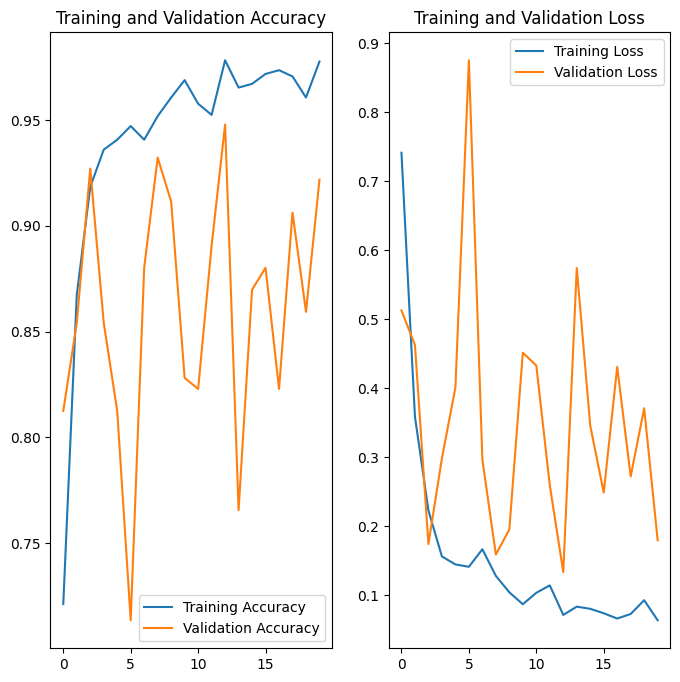

In [33]:
# Accuracy 
plt.figure(figsize=(8,8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

# LOSS
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

First image to predict
actual label :  Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step
Predicted label :  Potato___Early_blight


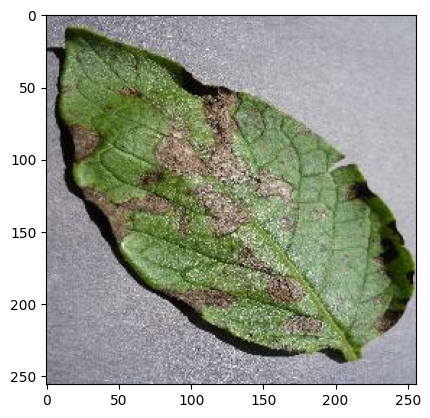

In [34]:
for image_batch, label_batch in test_ds.take(1):
    # plt.imshow(image_batch[0].numpy().astype('uint8'))
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    
    print("First image to predict")
    plt.imshow(first_image)
    print("actual label : ",class_names[first_label])

    # Let get the predicted class fri for first img
    batch_prediction = model.predict(image_batch)  # Output is a 3 values list, choose max probability
    prediction_class_val = np.argmax(batch_prediction[0])
    pred_class = class_names[prediction_class_val]
    print("Predicted label : ",pred_class)

### Function for prediction

In [35]:
# Takes : a trained model & one image
# Returns : predicted class & confidence %
# Since CNN models are designed to process BATCHES of images not single raw images 
# we have to create fake batch using even for one image to get predictoin for that single image

def predict_func(model, img):
    # Converts image into numerical array (tensor values / pixel matrix)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # Add batch dimension bcs CNN expects : (batch, height, width, channels), But one image is (height, width, channels) so this will add
    # (256,256,3) >>> (1,256,256,3) : batch size becomes 1
    img_array = tf.expand_dims(img_array, 0)

    # result in format [[a, b, c]], 0 < a, b, c < 1
    preds = model.predict(img_array)

    # find highest probability class
    predicted_class = class_names[np.argmax(preds[0])]

    # How sure the model is about its prediction
    confidence = round(100*(np.max(preds[0])), 2)

    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


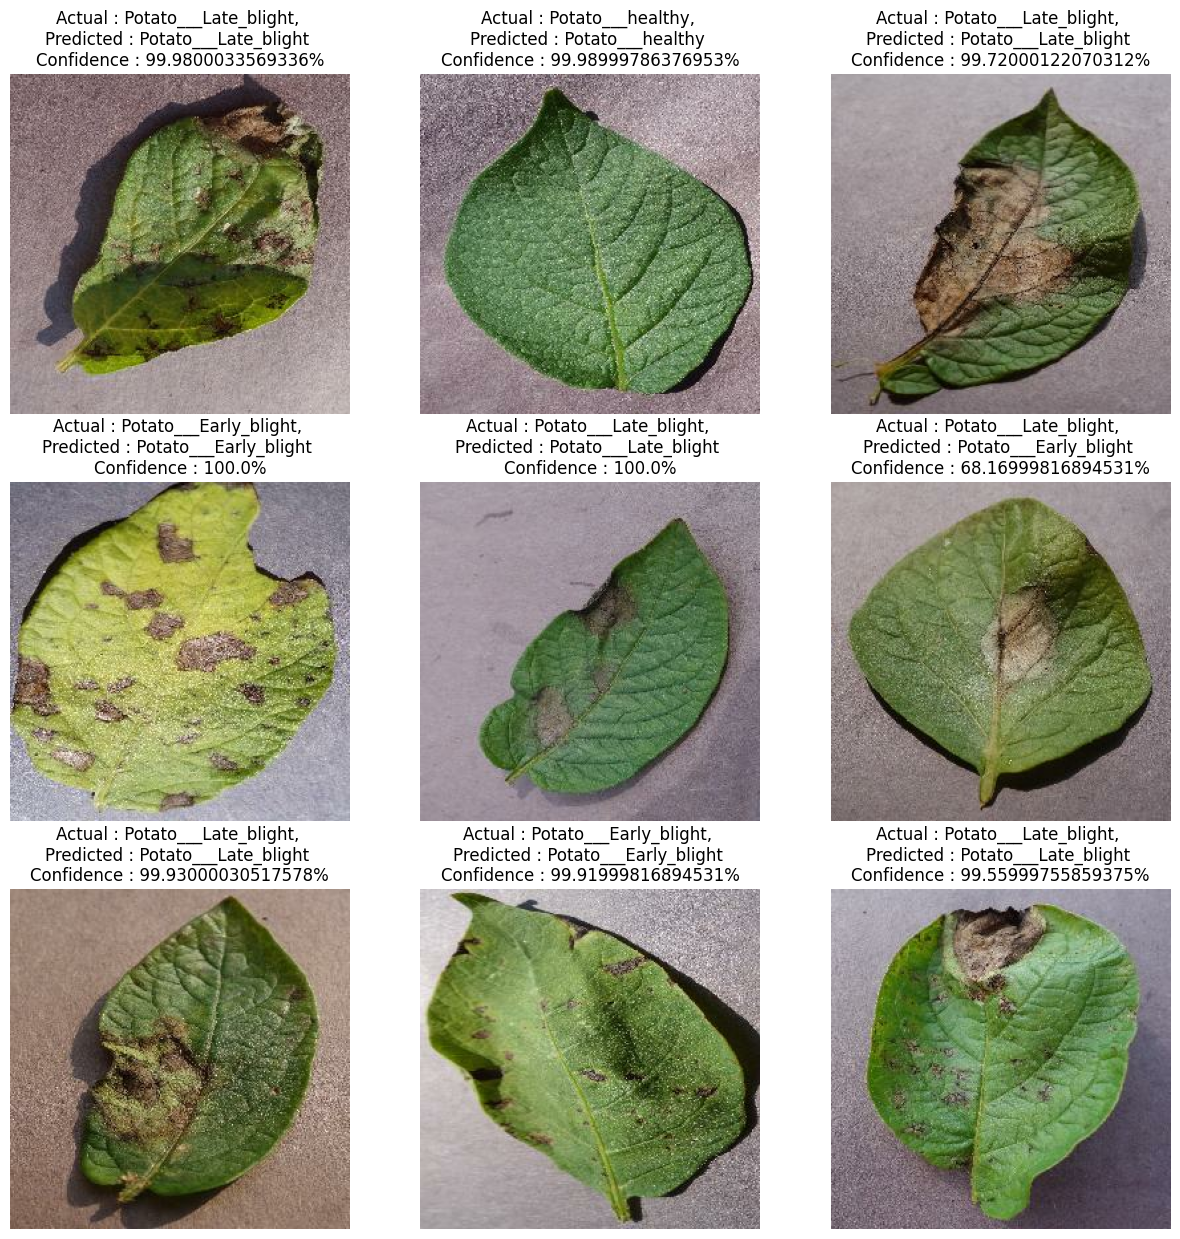

In [36]:
plt.figure(figsize=(15, 15))

# Let get first batch of images in test_ds
for images, labels in test_ds.take(1):

    # consider only 9 images in the batch
    for i in range(9):
        # define the place in the figure
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))

        predicted_class, confidence = predict_func(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual : {actual_class}, \nPredicted : {predicted_class} \nConfidence : {confidence}%")
        plt.axis('off')

### Save the models

In [37]:
# Newer Keras versions require a file extension when saving models
'''
model_version = 1
model.save(f"../saved_models/{model_version}.keras")
'''
# TensorFlow SavedModel format
# model.export(f"../models/{model_version}")

'\nmodel_version = 1\nmodel.save(f"../saved_models/{model_version}.keras")\n'

#### Auto define the model verison as int values

In [48]:
import os

path = "../saved_models"

versions = [ int(d.split('.')[0]) for d in os.listdir(path) if d.isdigit() ]
print(versions)

model_version =  max(versions) + 1 if versions else 1 # get the current max, then increase by 1
print(model_version)
model.save(f"../saved_models/{model_version}.keras")

[]
1


### Exporting
##### Instead of saving as name.keras we can use exporting as dir, Inn TF Serving thery expect the dir format

In [41]:
model.export("../saved_models/export/2")

INFO:tensorflow:Assets written to: ../saved_models/export/2\assets


INFO:tensorflow:Assets written to: ../saved_models/export/2\assets


Saved artifact at '../saved_models/export/2'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2776788305344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788306400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788545280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788543696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788547744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788548272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788548976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788717056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788716176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788715472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2776788547392: TensorSpec(

In [38]:
print(tf.__version__)

2.21.0
